In [ ]:
import numpy as np
data = np.load('mnist.npz')
X_train = data['x_train'].reshape(-1, 784) / 255.0 # (60000, 784)
Y_train = data['y_train'] # (60000,)
X_test = data['x_test'].reshape(-1, 784) / 255.0 # (10000, 784)
Y_test = data['y_test'] # (10000,)

In [ ]:
import numpy as np

def sigmoid(z):
    # Prevent overflow in exp for very large/small values
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [ ]:
def sigmoid_derivative(a):
    return a * (1 - a)

In [ ]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    # Layer 1
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    # Layer 2
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # Output layer
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    return Z1, A1, Z2, A2, Z3, A3

In [ ]:
def mse_loss(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

In [ ]:
def backpropagation(X, Y_true, A1, A2, A3, W2, W3):
    m = X.shape[0]

    # Output layer delta
    delta3 = 2 * (A3 - Y_true) * sigmoid_derivative(A3)

    # Gradients for W3, b3
    dW3 = (A2.T @ delta3) / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m

    # Hidden layer 2 delta
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)

    # Gradients for W2, b2
    dW2 = (A1.T @ delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m

    # Hidden layer 1 delta
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)

    # Gradients for W1, b1
    dW1 = (X.T @ delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [ ]:
def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3,
                   learning_rate):

    # Update weights
    W1 = W1 - learning_rate * dW1
    W2 = W2 - learning_rate * dW2
    W3 = W3 - learning_rate * dW3

    # Update biases
    b1 = b1 - learning_rate * db1
    b2 = b2 - learning_rate * db2
    b3 = b3 - learning_rate * db3

    return W1, b1, W2, b2, W3, b3

In [ ]:
def accuracy(X, Y_labels, W1, b1, W2, b2, W3, b3):
    _, _, _, _, _, A3 = forward_pass(X, W1, b1, W2, b2, W3, b3)
    preds = np.argmax(A3, axis=1)
    return np.mean(preds == Y_labels)

In [ ]:
learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []
np.random.seed(42)
b1 = np.zeros((1, 128))
b2 = np.zeros((1, 64))
b3 = np.zeros((1, 10))
W1 = np.random.uniform(-0.5, 0.5, (784, 128))
W2 = np.random.uniform(-0.5, 0.5, (128, 64))
W3 = np.random.uniform(-0.5, 0.5, (64, 10))
# One-hot encoding
Y_train_oh = np.eye(10)[Y_train]   # shape (60000, 10)
Y_test_oh = np.eye(10)[Y_test]     # shape (10000, 10)

for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    for start in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuf[start:start + batch_size]
        Y_batch = Y_shuf[start:start + batch_size]

        # Forward pass
        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)

        # Loss
        loss = mse_loss(Y_batch, A3)

        # Backprop
        dW1, db1, dW2, db2, dW3, db3 = backpropagation(
            X_batch, Y_batch, A1, A2, A3, W2, W3
        )

        # Update
        W1, b1, W2, b2, W3, b3 = update_weights(
            W1, b1, W2, b2, W3, b3,
            dW1, db1, dW2, db2, dW3, db3,
            learning_rate
        )

    # Epoch loss
    _, _, _, _, _, A3_full = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)

    train_acc = accuracy(X_train[:5000], Y_train[:5000], W1, b1, W2, b2, W3, b3)
    test_acc = accuracy(X_test, Y_test, W1, b1, W2, b2, W3, b3)

    print(f"Epoch {epoch + 1}/{epochs} Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/20 Loss: 0.0296 | Train Acc: 0.8562 | Test Acc: 0.8557
Epoch 2/20 Loss: 0.0208 | Train Acc: 0.8962 | Test Acc: 0.8934
Epoch 3/20 Loss: 0.0172 | Train Acc: 0.9090 | Test Acc: 0.9088
Epoch 4/20 Loss: 0.0153 | Train Acc: 0.9232 | Test Acc: 0.9176
Epoch 5/20 Loss: 0.0138 | Train Acc: 0.9282 | Test Acc: 0.9236
Epoch 6/20 Loss: 0.0127 | Train Acc: 0.9356 | Test Acc: 0.9281
Epoch 7/20 Loss: 0.0119 | Train Acc: 0.9410 | Test Acc: 0.9336
Epoch 8/20 Loss: 0.0111 | Train Acc: 0.9438 | Test Acc: 0.9344
Epoch 9/20 Loss: 0.0105 | Train Acc: 0.9478 | Test Acc: 0.9384
Epoch 10/20 Loss: 0.0100 | Train Acc: 0.9494 | Test Acc: 0.9413
Epoch 11/20 Loss: 0.0095 | Train Acc: 0.9528 | Test Acc: 0.9430
Epoch 12/20 Loss: 0.0091 | Train Acc: 0.9544 | Test Acc: 0.9452
Epoch 13/20 Loss: 0.0088 | Train Acc: 0.9554 | Test Acc: 0.9480
Epoch 14/20 Loss: 0.0084 | Train Acc: 0.9582 | Test Acc: 0.9490
Epoch 15/20 Loss: 0.0081 | Train Acc: 0.9594 | Test Acc: 0.9497
Epoch 16/20 Loss: 0.0078 | Train Acc: 0.9614 | Te

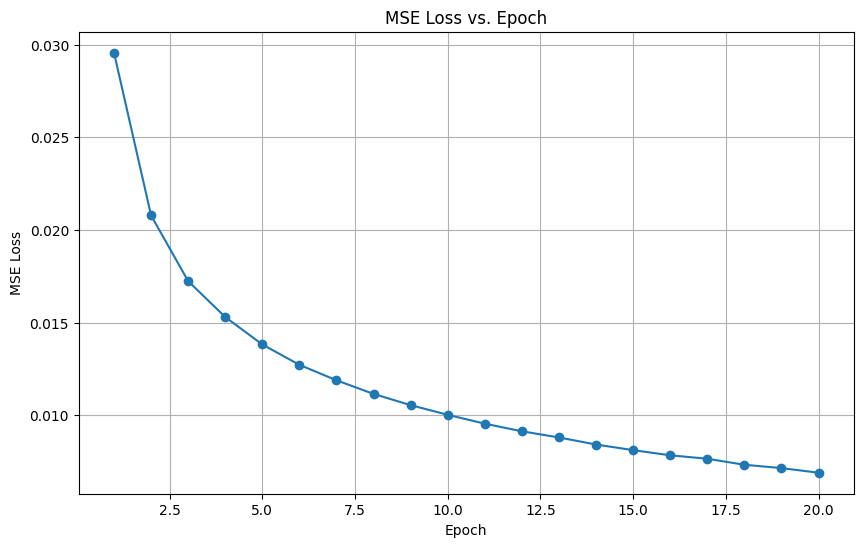

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-')
plt.title('MSE Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

In [ ]:
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

Final Test Accuracy: 95.54%


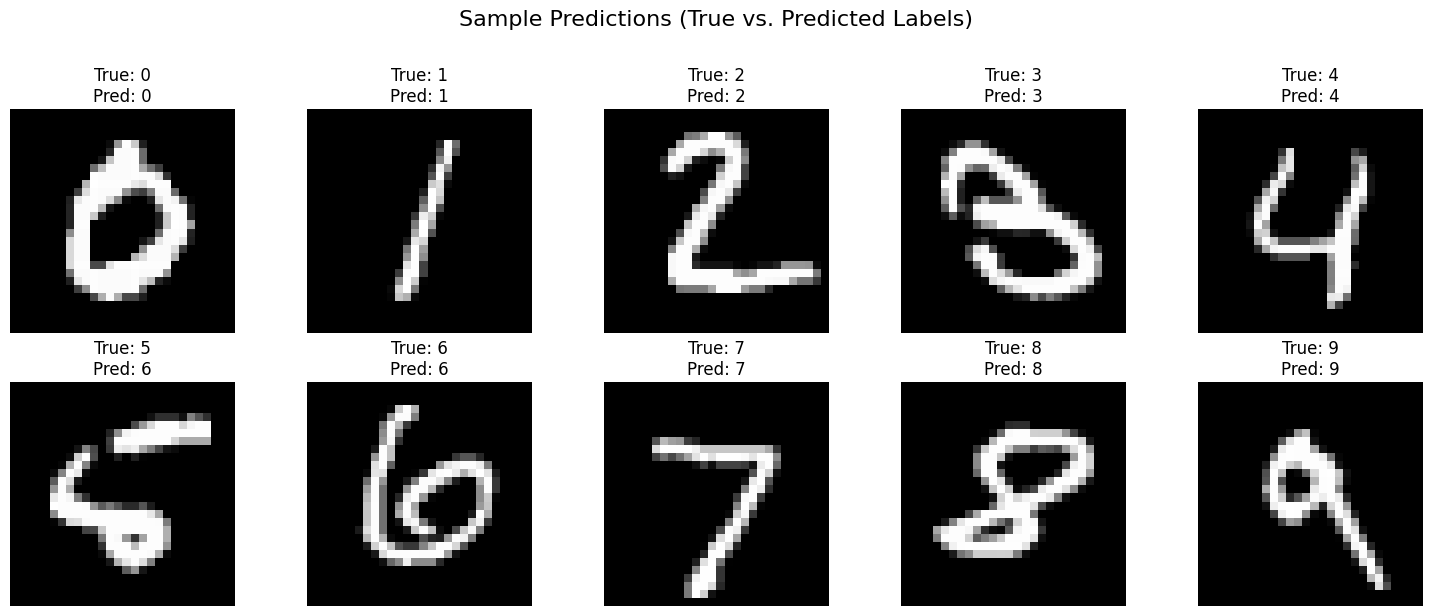

In [ ]:
num_samples_to_display = 10

# Find one image for each digit class (0-9)
digit_indices = {}
for i in range(len(Y_test)):
    digit = Y_test[i]
    if digit not in digit_indices:
        digit_indices[digit] = i
    if len(digit_indices) == num_samples_to_display:
        break

# Sort by digit for consistent display
sorted_digit_indices = sorted(digit_indices.items())

plt.figure(figsize=(15, 6))

for i, (digit, index) in enumerate(sorted_digit_indices):
    # Get the image and its true label
    image_flat = X_test[index]
    true_label = Y_test[index]

    # Reshape for display
    image_2d = image_flat.reshape(28, 28)

    # Make a prediction for this single image
    # The forward_pass expects a batch, so we need to reshape image_flat to (1, 784)
    _, _, _, _, _, A3_single = forward_pass(image_flat.reshape(1, -1), W1, b1, W2, b2, W3, b3)
    predicted_label = np.argmax(A3_single)

    # Create subplot
    plt.subplot(2, 5, i + 1) # 2 rows, 5 columns
    plt.imshow(image_2d, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.suptitle('Sample Predictions (True vs. Predicted Labels)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()